# Spatial Block Cross-Validation for GPR

This notebook evaluates the baseline GPR model using spatial block cross-validation.

**Why Spatial Blocking?**
- Groups nearby sites together to create spatially coherent folds
- Prevents information leakage from spatially autocorrelated observations
- More robust than random CV for spatially structured data
- Balances between LOSO (too pessimistic for some use cases) and random split (too optimistic)

**Approach:**
- Use K-means clustering on site coordinates to create spatial blocks
- Each fold holds out one spatial block
- Typical choice: 5-10 folds depending on number of sites

In [1]:
import pandas as pd
import numpy as np
import torch
import gpytorch
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from tqdm import tqdm
import time
import warnings
warnings.filterwarnings('ignore')

# Import timing utilities
from timing_utils import TimingLogger, Timer

np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Initialize timing logger
timing_log = TimingLogger("timings/gpr_timings.csv", experiment_name="spatial_cv")
print("Timing will be logged to timings/gpr_timings.csv")

/home/vcaristo/miniconda3/envs/patel/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
Timing will be logged to timings/gpr_timings.csv


## 1. Load and Prepare Data

In [2]:
# Load datasets
pm_all = pd.read_csv("../data/pm25_data_complete_2003-2021_nodups_051922.csv", low_memory=False)
pm_fixed = pd.read_csv('../eda/pm25_locs_with_states.csv')

# Filter to Montana
mt_sites = pm_fixed[pm_fixed['state'] == 'MT'].copy()
mt_ll_ids = set(mt_sites['ll_id'].values)

# Parse date and filter to 2019
pm_all['date'] = pd.to_datetime(pm_all['date'], format='%Y%m%d')
pm_all['year'] = pm_all['date'].dt.year
pm_mt = pm_all[(pm_all['ll_id'].isin(mt_ll_ids)) & (pm_all['year'] == 2019)].copy()

print(f"Montana 2019: {len(pm_mt):,} observations from {pm_mt['ll_id'].nunique()} sites")

Montana 2019: 8,043 observations from 32 sites


In [ ]:
# Define features
time_varying_features = ['aot', 'wind', 'hgt', 'cld', 'longwave', 'rh', 'tmax', 'cadI', 'smogP']
static_features = ['lat', 'lon', 'logpd2500g', 'minf_5000', 'sd50k', 
                   'heavy_industrial_ind1', 'housing']

available_tv = [f for f in time_varying_features if f in pm_mt.columns]
available_static = [f for f in static_features if f in mt_sites.columns]

# Merge datasets
pm_mt_subset = pm_mt[['ll_id', 'date', 'pm25'] + available_tv].copy()
mt_static = mt_sites[['ll_id'] + available_static].copy()
df = pm_mt_subset.merge(mt_static, on='ll_id', how='left')

feature_cols = available_tv + available_static
df_clean = df.dropna(subset=feature_cols + ['pm25']).copy()

print(f"Clean data: {len(df_clean):,} observations")

## 2. Create Spatial Blocks

In [4]:
# Get unique site coordinates
site_coords = df_clean.groupby('ll_id')[['lat', 'lon']].first().reset_index()
print(f"Number of sites: {len(site_coords)}")

# Display coordinate range
print(f"Latitude range: {site_coords['lat'].min():.2f} to {site_coords['lat'].max():.2f}")
print(f"Longitude range: {site_coords['lon'].min():.2f} to {site_coords['lon'].max():.2f}")

Number of sites: 28
Latitude range: 44.66 to 48.51
Longitude range: -115.67 to -104.48


In [5]:
# Choose number of folds
# Rule of thumb: sqrt(n_sites) or 5-10 folds
N_FOLDS = min(10, max(5, int(np.sqrt(len(site_coords)))))
print(f"Using {N_FOLDS} spatial folds")

# K-means clustering on coordinates
coords = site_coords[['lat', 'lon']].values

# Scale coordinates (important for K-means)
coord_scaler = StandardScaler()
coords_scaled = coord_scaler.fit_transform(coords)

# Cluster
kmeans = KMeans(n_clusters=N_FOLDS, random_state=42, n_init=10)
site_coords['fold'] = kmeans.fit_predict(coords_scaled)

print(f"\nSites per fold:")
print(site_coords['fold'].value_counts().sort_index())

Using 5 spatial folds



Sites per fold:
fold
0     6
1     5
2     4
3    10
4     3
Name: count, dtype: int64


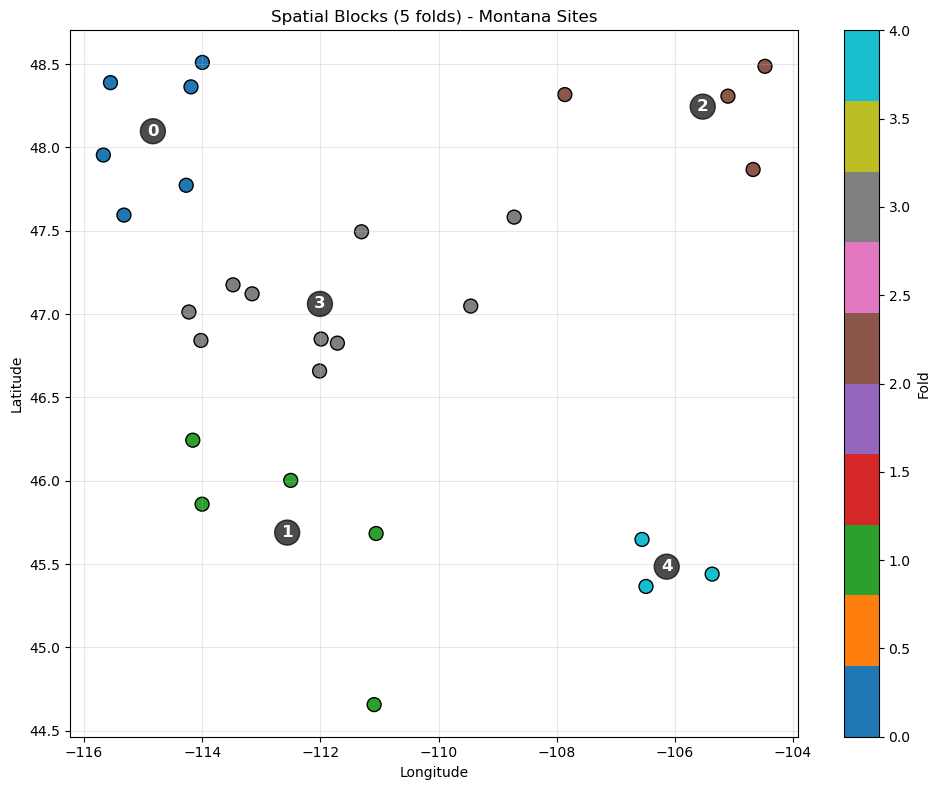

In [6]:
# Visualize spatial blocks
plt.figure(figsize=(10, 8))
scatter = plt.scatter(site_coords['lon'], site_coords['lat'], 
                      c=site_coords['fold'], cmap='tab10', s=100, edgecolors='black')
plt.colorbar(scatter, label='Fold')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title(f'Spatial Blocks ({N_FOLDS} folds) - Montana Sites')
plt.grid(True, alpha=0.3)

# Add fold labels
for fold in range(N_FOLDS):
    fold_sites = site_coords[site_coords['fold'] == fold]
    centroid_lon = fold_sites['lon'].mean()
    centroid_lat = fold_sites['lat'].mean()
    plt.annotate(f'{fold}', (centroid_lon, centroid_lat), fontsize=12, fontweight='bold',
                 ha='center', va='center', color='white',
                 bbox=dict(boxstyle='circle', facecolor='black', alpha=0.7))

plt.tight_layout()
plt.show()

In [7]:
# Map fold assignments to observations
site_fold_map = site_coords.set_index('ll_id')['fold'].to_dict()
df_clean['fold'] = df_clean['ll_id'].map(site_fold_map)

print("Observations per fold:")
print(df_clean['fold'].value_counts().sort_index())

Observations per fold:
fold
0    1389
1    1560
2     927
3    2836
4     839
Name: count, dtype: int64


## 3. Define GP Model

In [8]:
class ExactGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood, n_features):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel(ard_num_dims=n_features)
        )
    
    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)


def train_gp(train_x, train_y, n_features, n_epochs=50, lr=0.1):
    likelihood = gpytorch.likelihoods.GaussianLikelihood().to(device)
    model = ExactGPModel(train_x, train_y, likelihood, n_features).to(device)
    
    model.train()
    likelihood.train()
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)
    
    for _ in range(n_epochs):
        optimizer.zero_grad()
        output = model(train_x)
        loss = -mll(output, train_y)
        loss.backward()
        optimizer.step()
    
    return model, likelihood


def predict_gp(model, likelihood, test_x):
    model.eval()
    likelihood.eval()
    
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        pred = likelihood(model(test_x))
        return pred.mean.cpu().numpy(), pred.variance.cpu().numpy()

## 4. Run Spatial Block CV

In [9]:
MAX_TRAIN_SIZE = 2000
N_EPOCHS = 50

# Storage
all_predictions = []
all_actuals = []
all_variances = []
fold_metrics = []
fold_timings = []

print(f"Running {N_FOLDS}-fold spatial block CV...\n")

cv_start = time.perf_counter()

for fold in tqdm(range(N_FOLDS), desc="Spatial CV"):
    fold_start = time.perf_counter()
    
    # Split data
    test_mask = df_clean['fold'] == fold
    train_df = df_clean[~test_mask]
    test_df = df_clean[test_mask]
    
    if len(test_df) == 0:
        print(f"  Fold {fold}: No test data, skipping")
        continue
    
    # Extract features and target
    X_train = train_df[feature_cols].values
    y_train = np.log(train_df['pm25'].values + 1)
    X_test = test_df[feature_cols].values
    y_test = np.log(test_df['pm25'].values + 1)
    
    # Standardize
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Subsample training
    n_train_actual = len(X_train_scaled)
    if len(X_train_scaled) > MAX_TRAIN_SIZE:
        idx = np.random.choice(len(X_train_scaled), MAX_TRAIN_SIZE, replace=False)
        X_train_scaled = X_train_scaled[idx]
        y_train = y_train[idx]
        n_train_actual = MAX_TRAIN_SIZE
    
    # Convert to tensors
    train_x = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
    train_y = torch.tensor(y_train, dtype=torch.float32).to(device)
    test_x = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
    
    # Train with timing
    train_start = time.perf_counter()
    model, likelihood = train_gp(train_x, train_y, len(feature_cols), N_EPOCHS)
    train_time = time.perf_counter() - train_start
    
    # Predict with timing
    infer_start = time.perf_counter()
    pred_mean, pred_var = predict_gp(model, likelihood, test_x)
    infer_time = time.perf_counter() - infer_start
    
    fold_time = time.perf_counter() - fold_start
    
    # Store
    all_predictions.extend(pred_mean)
    all_actuals.extend(y_test)
    all_variances.extend(pred_var)
    
    # Fold metrics
    fold_rmse = np.sqrt(np.mean((pred_mean - y_test)**2))
    fold_mae = np.mean(np.abs(pred_mean - y_test))
    ss_res = np.sum((y_test - pred_mean)**2)
    ss_tot = np.sum((y_test - np.mean(y_test))**2)
    fold_r2 = 1 - (ss_res / ss_tot) if ss_tot > 0 else np.nan
    
    n_sites_fold = test_df['ll_id'].nunique()
    fold_metrics.append({
        'fold': fold,
        'n_sites': n_sites_fold,
        'n_obs': len(test_df),
        'rmse_log': fold_rmse,
        'mae_log': fold_mae,
        'r2_log': fold_r2
    })
    
    # Store timing
    fold_timings.append({
        'fold': fold,
        'n_train': n_train_actual,
        'n_test': len(test_df),
        'train_time': train_time,
        'infer_time': infer_time,
        'fold_time': fold_time
    })
    
    # Cleanup
    del model, likelihood
    torch.cuda.empty_cache() if torch.cuda.is_available() else None

cv_total_time = time.perf_counter() - cv_start

# Log total CV time
timing_log.log("spatial_cv_total", cv_total_time,
               n_folds=N_FOLDS, n_features=len(feature_cols), n_epochs=N_EPOCHS)

print(f"\nSpatial block CV complete!")
print(f"Total CV time: {cv_total_time:.1f}s ({cv_total_time/60:.1f} min)")

Running 5-fold spatial block CV...



Spatial CV:   0%|          | 0/5 [00:00<?, ?it/s]

Spatial CV:  20%|██        | 1/5 [00:02<00:11,  2.92s/it]

Spatial CV:  40%|████      | 2/5 [00:04<00:06,  2.01s/it]

Spatial CV:  60%|██████    | 3/5 [00:05<00:03,  1.71s/it]

Spatial CV:  80%|████████  | 4/5 [00:07<00:01,  1.59s/it]

Spatial CV: 100%|██████████| 5/5 [00:08<00:00,  1.53s/it]

Spatial CV: 100%|██████████| 5/5 [00:08<00:00,  1.70s/it]


Spatial block CV complete!
Total CV time: 8.5s (0.1 min)


## 5. Aggregate Results

In [10]:
# Convert to arrays
all_predictions = np.array(all_predictions)
all_actuals = np.array(all_actuals)

# Overall metrics - log scale
rmse_log = np.sqrt(np.mean((all_predictions - all_actuals)**2))
mae_log = np.mean(np.abs(all_predictions - all_actuals))
ss_res = np.sum((all_actuals - all_predictions)**2)
ss_tot = np.sum((all_actuals - np.mean(all_actuals))**2)
r2_log = 1 - (ss_res / ss_tot)

print("=" * 50)
print("Spatial Block CV Results - Log Scale")
print("=" * 50)
print(f"Total predictions: {len(all_predictions):,}")
print(f"RMSE: {rmse_log:.4f}")
print(f"MAE:  {mae_log:.4f}")
print(f"R²:   {r2_log:.4f}")

Spatial Block CV Results - Log Scale
Total predictions: 7,551
RMSE: 0.6642
MAE:  0.4959
R²:   0.1158


In [11]:
# Original scale
pred_pm25 = np.exp(all_predictions) - 1
actual_pm25 = np.exp(all_actuals) - 1

rmse_orig = np.sqrt(np.mean((pred_pm25 - actual_pm25)**2))
mae_orig = np.mean(np.abs(pred_pm25 - actual_pm25))
ss_res_orig = np.sum((actual_pm25 - pred_pm25)**2)
ss_tot_orig = np.sum((actual_pm25 - np.mean(actual_pm25))**2)
r2_orig = 1 - (ss_res_orig / ss_tot_orig)

print("\n" + "=" * 50)
print("Spatial Block CV Results - Original Scale (μg/m³)")
print("=" * 50)
print(f"RMSE: {rmse_orig:.2f}")
print(f"MAE:  {mae_orig:.2f}")
print(f"R²:   {r2_orig:.4f}")


Spatial Block CV Results - Original Scale (μg/m³)
RMSE: 4.85
MAE:  3.02
R²:   0.0978


In [12]:
# Fold-level summary
fold_df = pd.DataFrame(fold_metrics)
print("\nFold-level metrics:")
print(fold_df.to_string(index=False))

print("\nSummary statistics across folds:")
print(fold_df[['rmse_log', 'mae_log', 'r2_log']].describe())


Fold-level metrics:
 fold  n_sites  n_obs  rmse_log  mae_log    r2_log
    0        6   1389  0.562989 0.432514  0.367109
    1        5   1560  0.930011 0.702635 -0.307034
    2        4    927  0.465184 0.369812  0.150720
    3       10   2836  0.637538 0.488968  0.143477
    4        3    839  0.474441 0.379428  0.233659

Summary statistics across folds:
       rmse_log   mae_log    r2_log
count  5.000000  5.000000  5.000000
mean   0.614033  0.474671  0.117586
std    0.190159  0.136029  0.253873
min    0.465184  0.369812 -0.307034
25%    0.474441  0.379428  0.143477
50%    0.562989  0.432514  0.150720
75%    0.637538  0.488968  0.233659
max    0.930011  0.702635  0.367109


## 6. Visualizations

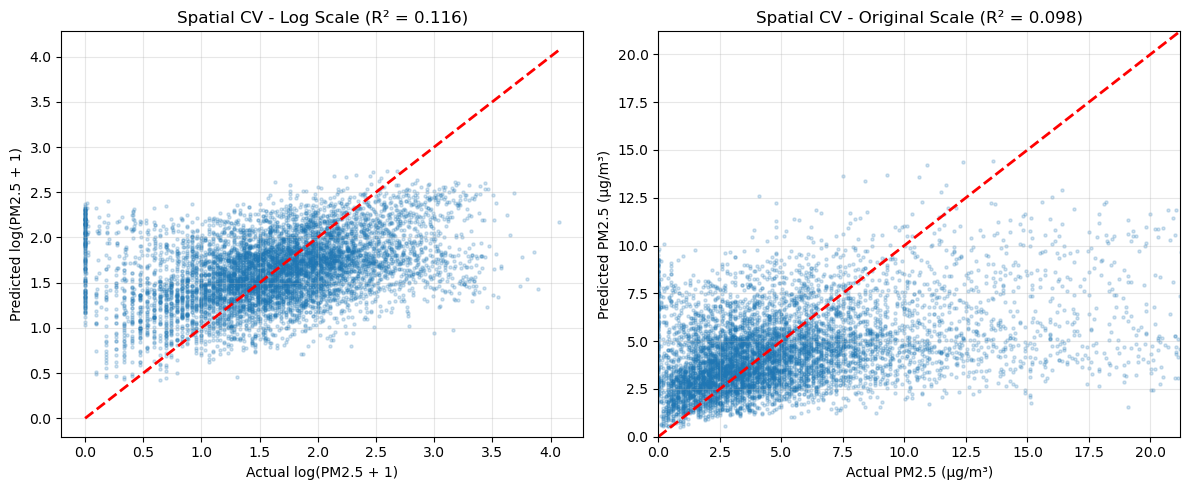

In [13]:
# Predictions vs Actual
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(all_actuals, all_predictions, alpha=0.2, s=5)
axes[0].plot([all_actuals.min(), all_actuals.max()], 
             [all_actuals.min(), all_actuals.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual log(PM2.5 + 1)')
axes[0].set_ylabel('Predicted log(PM2.5 + 1)')
axes[0].set_title(f'Spatial CV - Log Scale (R² = {r2_log:.3f})')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(actual_pm25, pred_pm25, alpha=0.2, s=5)
max_val = np.percentile(np.concatenate([actual_pm25, pred_pm25]), 99)
axes[1].plot([0, max_val], [0, max_val], 'r--', lw=2)
axes[1].set_xlabel('Actual PM2.5 (μg/m³)')
axes[1].set_ylabel('Predicted PM2.5 (μg/m³)')
axes[1].set_title(f'Spatial CV - Original Scale (R² = {r2_orig:.3f})')
axes[1].set_xlim(0, max_val)
axes[1].set_ylim(0, max_val)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

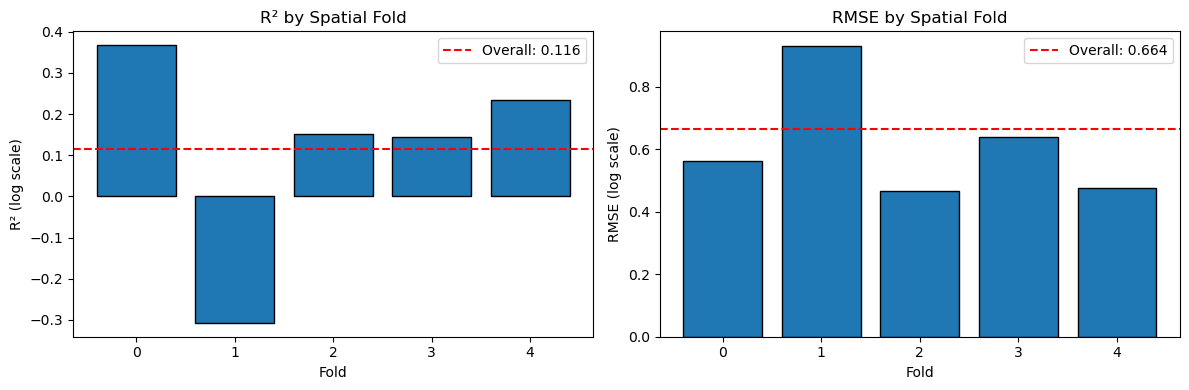

In [14]:
# Fold-level performance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# R² by fold
axes[0].bar(fold_df['fold'], fold_df['r2_log'], edgecolor='black')
axes[0].axhline(y=r2_log, color='r', linestyle='--', label=f'Overall: {r2_log:.3f}')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('R² (log scale)')
axes[0].set_title('R² by Spatial Fold')
axes[0].legend()

# RMSE by fold
axes[1].bar(fold_df['fold'], fold_df['rmse_log'], edgecolor='black')
axes[1].axhline(y=rmse_log, color='r', linestyle='--', label=f'Overall: {rmse_log:.3f}')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('RMSE (log scale)')
axes[1].set_title('RMSE by Spatial Fold')
axes[1].legend()

plt.tight_layout()
plt.show()

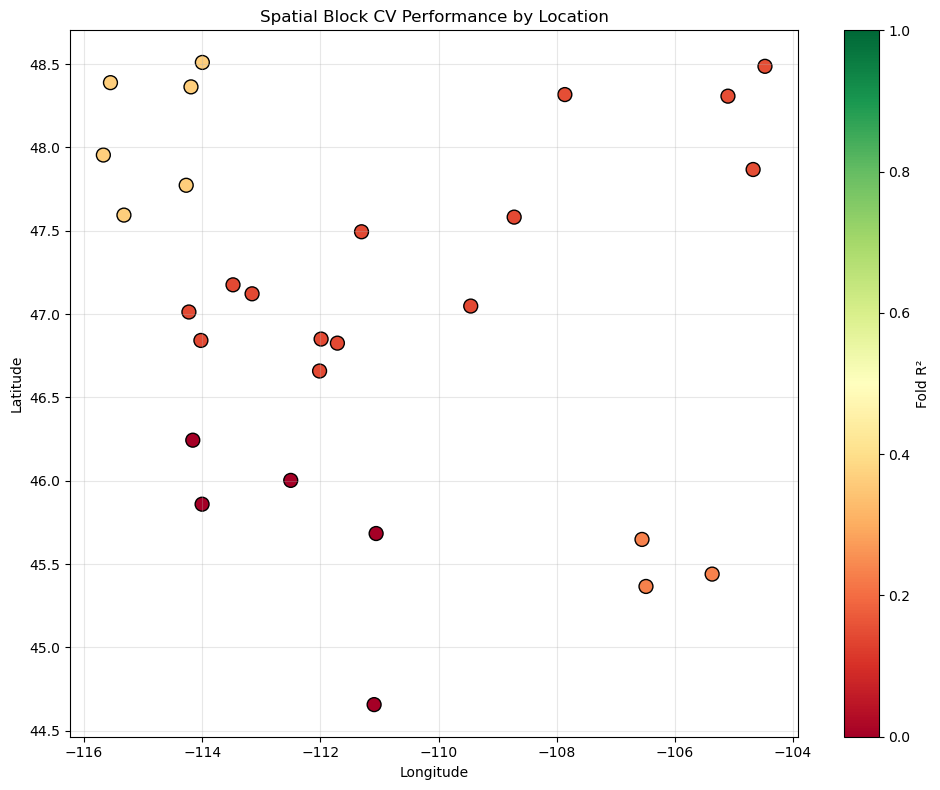

In [15]:
# Map of fold performance
# Merge R² back to site coordinates
site_coords_with_metrics = site_coords.merge(
    fold_df[['fold', 'r2_log']], on='fold', how='left'
)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(site_coords_with_metrics['lon'], 
                      site_coords_with_metrics['lat'],
                      c=site_coords_with_metrics['r2_log'], 
                      cmap='RdYlGn', s=100, edgecolors='black',
                      vmin=0, vmax=1)
plt.colorbar(scatter, label='Fold R²')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Spatial Block CV Performance by Location')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

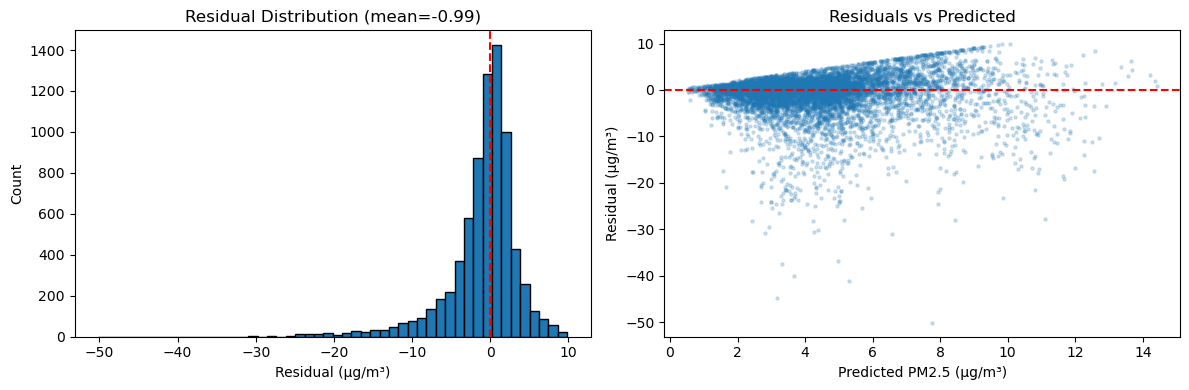

In [16]:
# Residual analysis
residuals = pred_pm25 - actual_pm25

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(residuals, bins=50, edgecolor='black')
axes[0].axvline(x=0, color='r', linestyle='--')
axes[0].set_xlabel('Residual (μg/m³)')
axes[0].set_ylabel('Count')
axes[0].set_title(f'Residual Distribution (mean={residuals.mean():.2f})')

axes[1].scatter(pred_pm25, residuals, alpha=0.2, s=5)
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].set_xlabel('Predicted PM2.5 (μg/m³)')
axes[1].set_ylabel('Residual (μg/m³)')
axes[1].set_title('Residuals vs Predicted')

plt.tight_layout()
plt.show()

## 7. Save Results

In [17]:
# Save fold metrics
fold_df.to_csv('results/spatial_cv_fold_metrics.csv', index=False)
print("Fold metrics saved to results/spatial_cv_fold_metrics.csv")

# Save overall results
results = {
    'cv_method': 'Spatial_Block',
    'n_folds': N_FOLDS,
    'n_predictions': len(all_predictions),
    'rmse_log': rmse_log,
    'mae_log': mae_log,
    'r2_log': r2_log,
    'rmse_orig': rmse_orig,
    'mae_orig': mae_orig,
    'r2_orig': r2_orig,
    'r2_log_std': fold_df['r2_log'].std(),
    'total_time_seconds': cv_total_time
}
pd.DataFrame([results]).to_csv('results/spatial_cv_overall_results.csv', index=False)
print("Overall results saved to results/spatial_cv_overall_results.csv")

# Save fold-level timing
timing_df = pd.DataFrame(fold_timings)
timing_df.to_csv('timings/spatial_cv_fold_timings.csv', index=False)
print("Fold timings saved to timings/spatial_cv_fold_timings.csv")

# Timing summary
print("\n" + "=" * 50)
print("Timing Summary")
print("=" * 50)
print(f"Total CV time: {cv_total_time:.1f}s ({cv_total_time/60:.1f} min)")
print(f"\nPer-fold timing (across {len(timing_df)} folds):")
print(f"  Training:  mean={timing_df['train_time'].mean():.2f}s, std={timing_df['train_time'].std():.2f}s")
print(f"  Inference: mean={timing_df['infer_time'].mean():.3f}s, std={timing_df['infer_time'].std():.3f}s")
print(f"  Total:     mean={timing_df['fold_time'].mean():.2f}s, std={timing_df['fold_time'].std():.2f}s")

# Show timing logger summary
timing_log.summary()

Fold metrics saved to results/spatial_cv_fold_metrics.csv
Overall results saved to results/spatial_cv_overall_results.csv
Fold timings saved to timings/spatial_cv_fold_timings.csv

Timing Summary
Total CV time: 8.5s (0.1 min)

Per-fold timing (across 5 folds):
  Training:  mean=1.57s, std=0.56s
  Inference: mean=0.063s, std=0.007s
  Total:     mean=1.69s, std=0.68s

Timing Summary: timings/gpr_timings.csv

training:
  Count: 1
  Mean:  3.048s
  Std:   nans
  Min:   3.048s
  Max:   3.048s

inference:
  Count: 1
  Mean:  0.079s
  Std:   nans
  Min:   0.079s
  Max:   0.079s

loso_cv_total:
  Count: 1
  Mean:  45.539s
  Std:   nans
  Min:   45.539s
  Max:   45.539s

spatial_cv_total:
  Count: 1
  Mean:  8.485s
  Std:   nans
  Min:   8.485s
  Max:   8.485s


,timestamp,experiment,operation,n_train,n_features,n_epochs,kernel,elapsed_seconds,n_test,batch_size,n_folds
0,2026-02-08T19:35:27.914688,baseline_random_split,training,2000.0,16,100.0,RBF_ARD,3.048240,NaN,NaN,NaN
1,2026-02-08T19:35:31.067357,baseline_random_split,inference,2000.0,16,NaN,NaN,0.079156,1511.0,500.0,NaN
2,2026-02-08T19:36:36.901326,loso_cv,loso_cv_total,NaN,16,50.0,NaN,45.539098,NaN,NaN,28.0
3,2026-02-08T19:37:05.013040,spatial_cv,spatial_cv_total,NaN,16,50.0,NaN,8.484749,NaN,NaN,5.0


## 8. Comparison Summary

After running all three evaluation methods, compare:

| Method | Expected R² | Notes |
|--------|-------------|-------|
| Random Split | Highest | Optimistic due to same-site leakage |
| Spatial Block | Middle | Balances spatial independence with sample size |
| LOSO | Lowest | Most conservative, tests true spatial generalization |

The difference between these estimates indicates how much the model relies on site-specific patterns vs. generalizable covariate relationships.